# Getting started

There are two main use cases for `jwpoint` at the moment:

1. finding the science target/pointing position in an observation
2. selecting an optimal pointing position when planning observations

The latter use case is a bit more involved and is discussed in the [Optimizing Pointing tutorial](optimize-pointing.ipynb),
so we will only demonstrate the first use-case in this tutorial.

We will use data from program 4903 since the data is public and consists of wide-field images.
This means that the science targets (galaxies in this case) cannot be found by eye easily,
making it a good demonstration case for `jwpoint`.

## Downloading a science observation

Let us first download a science observation in one of the supported filter.
We will use [Mastodown](https://mastodown.readthedocs.io/en/latest/) to find and download a file.

In [1]:
import mastodown

products = mastodown.query_obs(
    programs="04903",
    target_name="MRGS1522",
    filters="F444W",
    instrument_name="NIRCAM/IMAGE",
    calib_level=[2],
    product_type="science",
    product_subgroup="cal",
)
products

INFO: 3 of 48 products were duplicates. Only returning 45 unique product(s). [astroquery.mast.utils]
INFO: To return all products, use `Observations.get_product_list` [astroquery.mast.observations]


,target_name,obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,...,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level,filters
0,MRGS1522,243899482,JWST,image,jw04903002001_02101_00001_nrcblong,exposure (L2b): 2D calibrated exposure average...,S,mast:JWST/product/jw04903002001_02101_00001_nr...,SCIENCE,NaN,...,NaN,CALJWST,2.0.1,4903,jw04903002001_02101_00001_nrcblong_cal.fits,117573120,243907856,PUBLIC,2,F444W
1,MRGS1522,243899451,JWST,image,jw04903002001_02101_00002_nrcblong,exposure (L2b): 2D calibrated exposure average...,S,mast:JWST/product/jw04903002001_02101_00002_nr...,SCIENCE,NaN,...,NaN,CALJWST,2.0.1,4903,jw04903002001_02101_00002_nrcblong_cal.fits,117573120,243907856,PUBLIC,2,F444W
2,MRGS1522,243899488,JWST,image,jw04903002001_02101_00003_nrcblong,exposure (L2b): 2D calibrated exposure average...,S,mast:JWST/product/jw04903002001_02101_00003_nr...,SCIENCE,NaN,...,NaN,CALJWST,2.0.1,4903,jw04903002001_02101_00003_nrcblong_cal.fits,117573120,243907856,PUBLIC,2,F444W


The three files should be similar so let us just download the first one.
They are somewhat voluminous (~100 Mb) so the download may take a while,
but Mastodown will use an existing file if found on subsequent runs, as shown here.

In [2]:
from mastodown import download_product

file_path = download_product(products.loc[1], download_dir="data")

## Previewing the file

Now that we have data, let us see what the images look like.

In [3]:
from astropy.io import fits
with fits.open(file_path) as hdul:
    hdr = hdul[0].header
    img = hdul[1].data

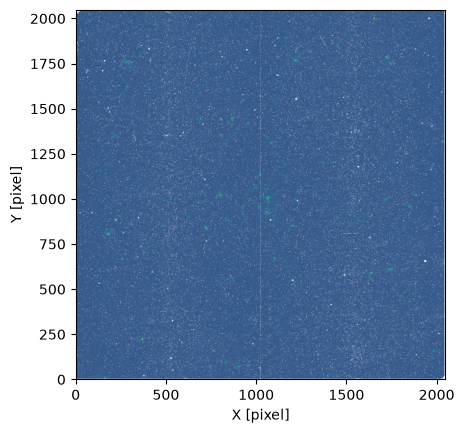

In [4]:
import matplotlib.pyplot as plt

plt.imshow(img, origin="lower", norm="symlog")
plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.show()

As mentioned above, it is hard to tell what is where in this wide field image.
Let's find the pointing position of our primary using `jwpoint`.

## Finding the science target

To find the science target, we need the pointing position of the telescope.
This can be computed from a reference position to which we apply the pointing offset
stored in the header's `XOFFSET` and `YOFFSET` keys.
The reference position is not stored in the header, but can be found on [JDocs](https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-operations/nircam-apertures#gsc.tab=0).
`jwpoint` also stores the reference position internally so we do not need to worry about them.

Finally, we need to pass the data file as an argument since this will define the [World Coordinate System (WCS)](https://docs.astropy.org/en/latest/wcs/index.html) used to transform between astrophysical and detector coordinates internally.

In [5]:
from jwpoint.pointing import get_pointing_position

xpos, ypos = get_pointing_position(hdr["XOFFSET"], hdr["YOFFSET"], file_path)

Now that we have the plotting position, let us overplot it on the image.

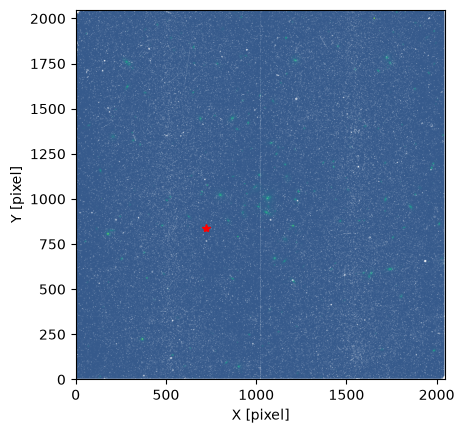

In [6]:
plt.imshow(img, origin="lower", norm="symlog")
plt.plot(xpos, ypos, "r*")
plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.show()

If our pointing calculation is correct, the galaxy should be hidden under the red star.
Let us zoom in to confirm this.

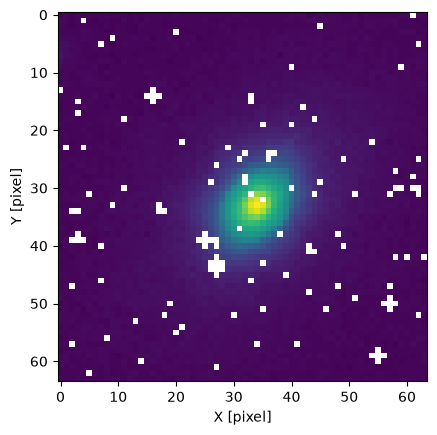

In [7]:
from jwpoint.plot import zoom_plot

zoom_plot(img, int(xpos), int(ypos), size=64, show_mask=False)
plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.show()

The pointing calculation worked as expected!
Feel free to change the science file and apply this to any of your observations.
If the instrument mode you are using is unsupported, it should be fairly easy to add it: feel free to open [an issue](https://github.com/vandalt/jwpoint/issues/new/choose) or a [pull request](https://github.com/vandalt/jwpoint/compare) on GitHub.

- To see how `jwpoint` can be useful to plan observations, see [Optimizing Pointing](optimize-pointing.ipynb)
- For a more in depth explanation on how pointing with JWST works, see [Understanding JWST pointing](understand-pointing.ipynb)